# Testing ResNet-18

In [22]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

import requests
from io import BytesIO

# --- load test image ---
# img = "dog.png"
# image = np.array(Image.open(img).convert("RGB").resize((224, 224)))
# print(f"Image shape: {image.shape}")  # expected: (224, 224, 3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
url = 'https://images.unsplash.com/photo-1640384974326-3e72680e0fb3?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D' # cat 73%
response = requests.get(url)
raw_img = Image.open(BytesIO(response.content)).convert('RGB')

# Resize and crop
resize_and_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

# Convert to tensor and normalize
tensor_and_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img = resize_and_crop(raw_img)

# Input image for the model
input_tensor = tensor_and_norm(img)
input_batch = input_tensor.unsqueeze(0).to(device)

# --- load resnet-18 ---
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.eval()

with torch.no_grad():
    predicted_class = resnet(input_batch).argmax(dim=1).item()
    print(f"Predicted class index: {predicted_class}")

def model(batch: np.ndarray) -> np.ndarray:
    """Wraps ResNet-18 to accept (N, H, W, C) numpy arrays and return (N,) predictions."""
    tensors = torch.stack([tensor_and_norm(img) for img in batch])
    with torch.no_grad():
        logits = resnet(tensors)  # (N, 1000)
    return logits[:, predicted_class].numpy()  # (N,) — only the relevant class


Predicted class index: 281


In [26]:
from shapiq import ImageExplainer
from shapiq.vision.masking import MeanColorMasking

# default for resnet is 10 players with Superpixel strategy
image = np.array(img)
explainer = ImageExplainer(model=model, data=image, model_type="resnet", masking_strategy=MeanColorMasking())
interaction_values_resnet = explainer.explain(budget=64)

print(f"n_players: {explainer.imputer.n_players}")
print(interaction_values_resnet)

n_players: 10
InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=64,
    n_players=10, baseline_value=0.825203001499176,
    Top 10 interactions:
        (7,): 9.548792919672136
        (9,): 8.567091925413738
        (2, 6): 2.348422049699183
        (2, 4): 1.8332158080417198
        (4, 8): -1.7525335025465916
        (2, 7): -1.8486928983984439
        (7, 9): -2.3884643655013114
        (1, 9): -2.5059935117451224
        (7, 8): -2.9666722795366707
        (0, 2): -3.056900381450413
)


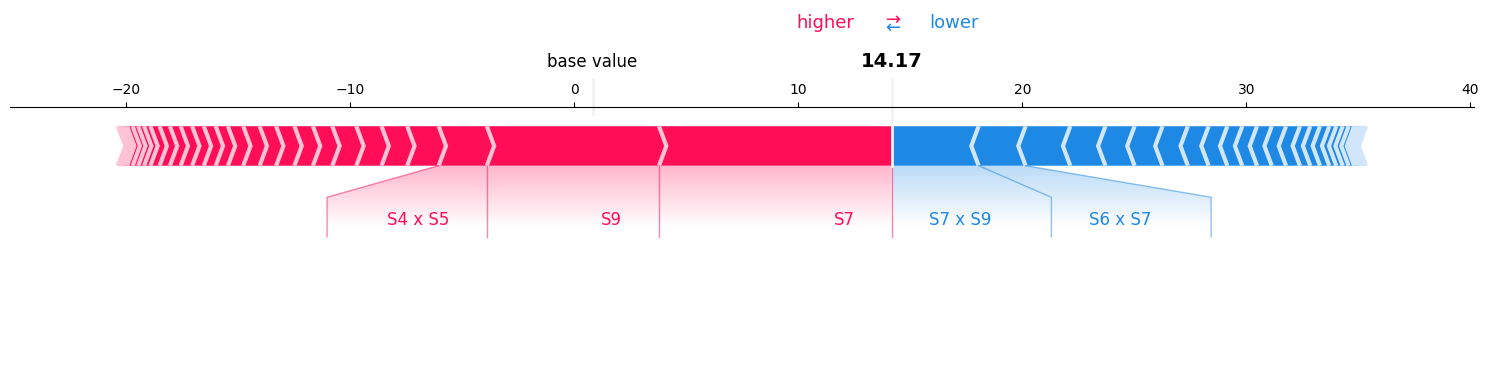

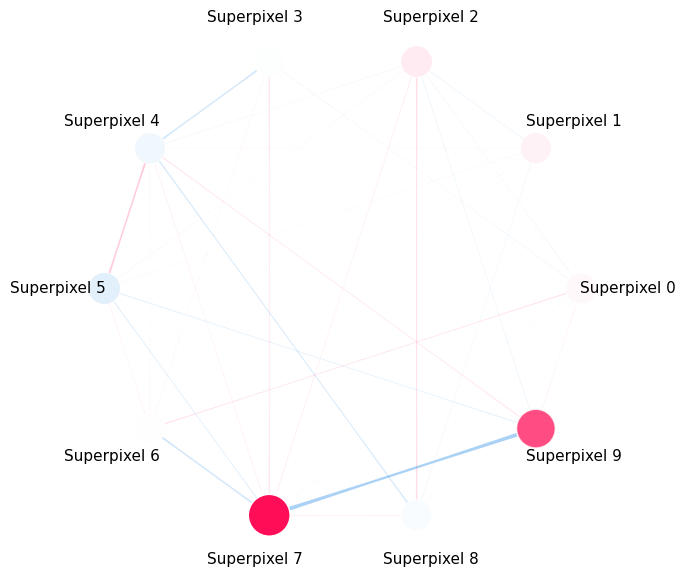

In [24]:
superpixels = [f"Superpixel {i}" for i in range(explainer.imputer.n_players)]
interaction_values_resnet.plot_force(feature_names=superpixels)
interaction_values_resnet.plot_network(feature_names=superpixels)

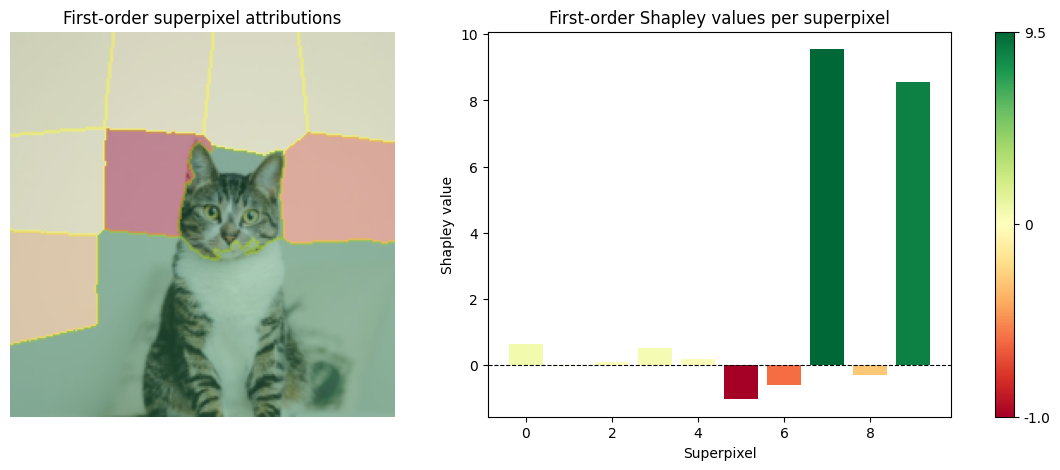

In [28]:
# heat map plot:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from skimage.segmentation import mark_boundaries

# get first-order values
first_order = interaction_values_resnet.get_n_order_values(1)

# build heatmap
heatmap = np.zeros(image.shape[:2])
for i in range(explainer.imputer.n_players):
    heatmap[explainer.imputer.player_masks[i]] = first_order[i]

# shared colormap and norm
cmap = cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=heatmap.min(), vcenter=0, vmax=heatmap.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- heatmap ---
axes[0].imshow(image)
hm = axes[0].imshow(heatmap, alpha=0.5, cmap=cmap, norm=norm)
axes[0].imshow(mark_boundaries(image, explainer.imputer.player_masks.argmax(axis=0) + 1), alpha=0.3)
axes[0].set_title("First-order superpixel attributions")
axes[0].axis("off")

# --- bar plot colored like heatmap ---
bar_colors = [cmap(norm(v)) for v in first_order]
axes[1].bar(range(explainer.imputer.n_players), first_order, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Superpixel")
axes[1].set_ylabel("Shapley value")
axes[1].set_title("First-order Shapley values per superpixel")

# colorbar for bar plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)
cbar.set_ticks([heatmap.min(), 0, heatmap.max()])
cbar.set_ticklabels([f"{heatmap.min():.1f}", "0", f"{heatmap.max():.1f}"])

plt.show()

# Testing ViT

In [16]:
import numpy as np
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

# Use patch32-384 to match 12x12 grid like _vit_setup.py
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch32-384")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch32-384")
model.eval()

# Match _vit_setup.py behavior: zero mask token
model.vit.embeddings.mask_token = torch.nn.Parameter(
    torch.zeros(1, 1, model.config.hidden_size)
)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [17]:
from shapiq import ImageExplainer

# default for vit is PatchStrategy(grid_size=12, n_players=9)
explainer = ImageExplainer(model=model, data=image, model_type="vit")
interaction_values_vit = explainer.explain(budget=64)

print(f"n_players: {explainer.imputer.n_players}")
print(interaction_values_vit)

n_players: 9
InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=64,
    n_players=9, baseline_value=0.0001953242754098028,
    Top 10 interactions:
        (7,): 0.5986343930679391
        (4,): 0.5569104704360461
        (0, 6): 0.15344314331007777
        (3, 4): 0.14067353993689216
        (5, 8): 0.09960107625662702
        (1, 2): 0.07928235508321742
        (2, 4): -0.08652504175941966
        (0, 7): -0.09973859916519899
        (3, 6): -0.13212906783998016
        (4, 7): -0.4025432171354375
)


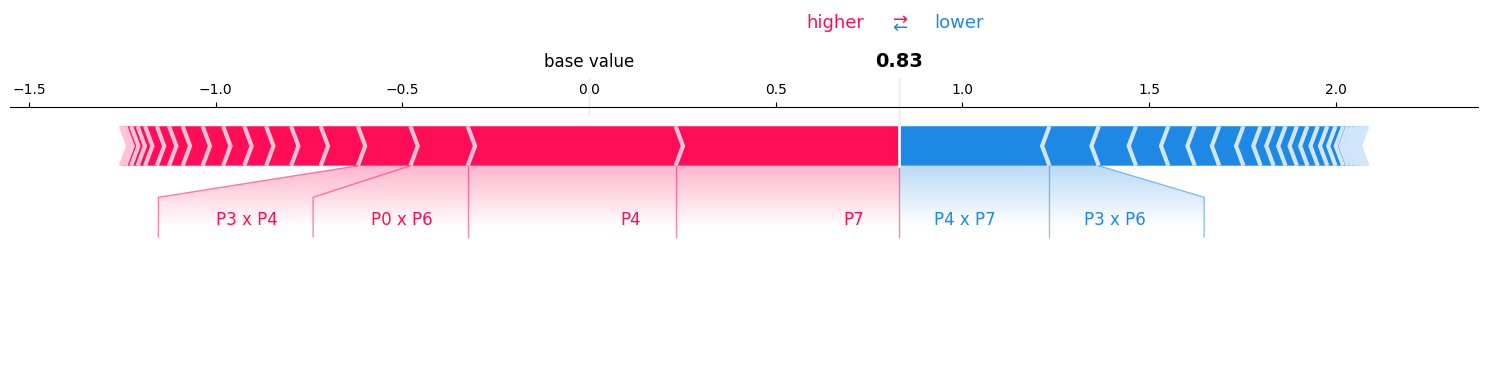

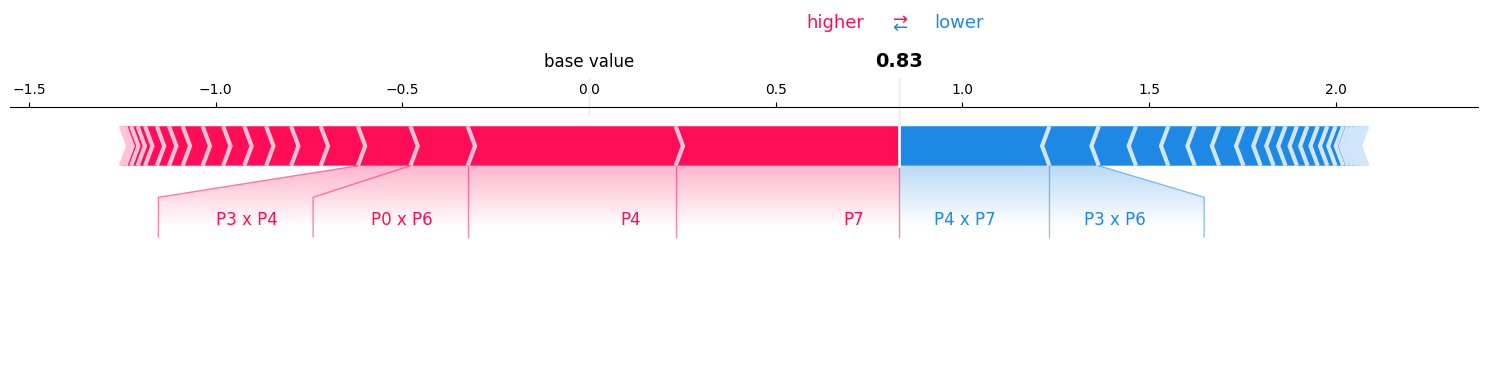

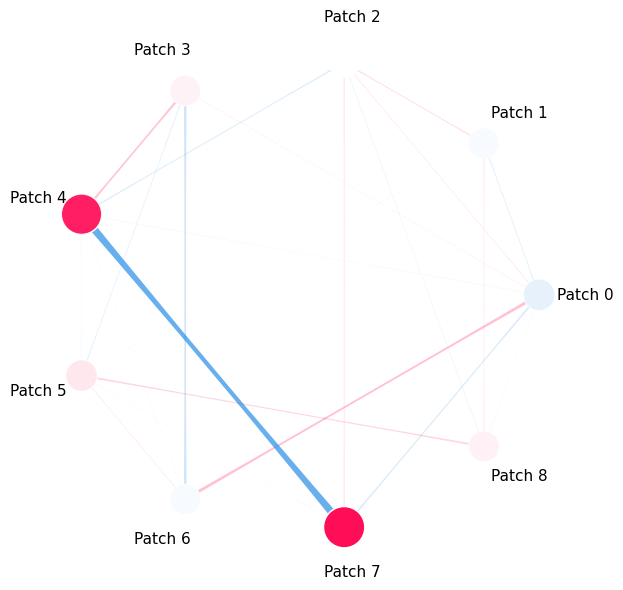

In [18]:
interaction_values_vit.plot_force(feature_names=[f"Patch {i}" for i in range(explainer.imputer.n_players)])
interaction_values_vit.plot_network(feature_names=[f"Patch {i}" for i in range(explainer.imputer.n_players)])

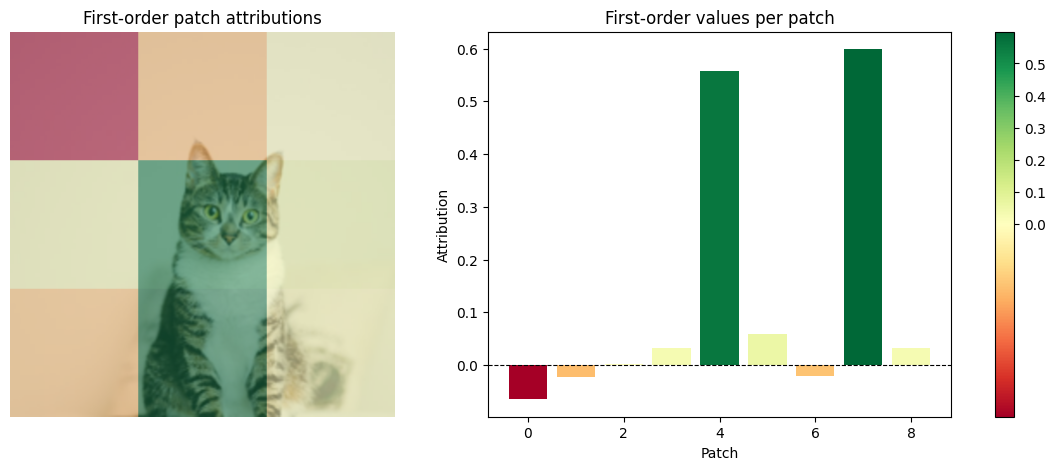

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# First-order (main effects)
first_order = interaction_values_vit.get_n_order_values(1)

# Rebuild patch grid params (in case this cell runs standalone)
image_size = model.config.image_size
patch_size = model.config.patch_size
grid_size = image_size // patch_size

n_players = explainer.imputer.n_players
side = int(np.sqrt(n_players))
block = grid_size // side

# Build heatmap on patch grid
heatmap_grid = np.zeros((grid_size, grid_size), dtype=float)
for p in range(n_players):
    y = (p // side) * block
    x = (p % side) * block
    heatmap_grid[y : y + block, x : x + block] = first_order[p]

# Upsample to pixel space
heatmap_img = np.kron(heatmap_grid, np.ones((patch_size, patch_size)))

# Resize image for alignment
image_resized = img.resize((image_size, image_size))

# Diverging colormap centered at 0
cmap = cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=heatmap_img.min(), vcenter=0, vmax=heatmap_img.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlay heatmap
axes[0].imshow(image_resized)
axes[0].imshow(heatmap_img, alpha=0.5, cmap=cmap, norm=norm)
axes[0].set_title("First-order patch attributions")
axes[0].axis("off")

# Bar plot
bar_colors = [cmap(norm(v)) for v in first_order]
axes[1].bar(range(n_players), first_order, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Patch")
axes[1].set_ylabel("Attribution")
axes[1].set_title("First-order values per patch")

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)

plt.show()